Olá, Luiz

Meu nome é Ramon. Ao ao longo do texto farei algumas observações sobre melhorias no código. Nas partes em que não houver comentários, está tudo certo, ok? Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser consertado, caso contrário seu projeto **não** será aceito.
</div>

Você pode me responder usando isso:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

###


<div class="alert alert-block alert-success">
<b>Comentário Geral do Revisor</b> <a class="tocSkip"></a>

Obrigado por enviar seu projeto. 
    
Parabéns, você fez um bom trabalho.

Como pontos fortes do projeto, destaco:
- Código simples e eficiente (sem loop desnecessário)
- Uso adequado dos recursos da lição


Parabéns pela dedicação. Desejo sucesso na jornada. Conte conosco.

***
Porém, há espaço para melhorias. Deixei dicas.



Portanto, sugiro que você corrija os pontos indicados.
    
Se você tiver alguma dúvida sobre de algo que você não tenha entendido, sinta-se à vontade para perguntar ao tutor ou deixar um comentário em **azul** para que, na próxima iteração, eu possa responder.

Conte conosco. Lembre-se de que você pode tirar dúvidas com revisores usando os comentários ou buscar ajuda de um tutor.
Bom trabalho. 


</div>


# Projeto feito por Luiz Trajano:

# Etapa 1: Abrindo o arquivo e analisando conteúdo

In [2]:
import pandas as pd
import os

path_local = 'games.csv'
path_tripleten = '/datasets/games.csv'

# Verifica qual caminho existe e carrega o DataFrame
if os.path.exists(path_tripleten):
    df = pd.read_csv(path_tripleten)
    print("Arquivo carregado da plataforma TripleTen")
elif os.path.exists(path_local):
    df = pd.read_csv(path_local)
    print("Arquivo carregado localmente (VS Code)")
else:
    print("Erro: Arquivo games.csv não encontrado!")

# Prefiro o sample para uma análise rápida variada
df.sample(5)

Arquivo carregado da plataforma TripleTen


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
12113,Ken to Mahou to Gakuen Mono. 3,PS3,2010.0,Role-Playing,0.00,0.00,0.07,0.00,NaN,NaN,NaN
6031,MLB Pennant Race,PS,1996.0,Sports,0.16,0.11,0.00,0.02,NaN,NaN,NaN
7797,Jikkyou Powerful Pro Yakyuu '96 Kaimakuban,SNES,1996.0,Sports,0.00,0.00,0.19,0.00,NaN,NaN,NaN
8545,Dewy's Adventure,Wii,2007.0,Platform,0.14,0.00,0.01,0.01,67.0,6.3,E
7265,Dead Island,PC,2011.0,Action,0.12,0.07,0.00,0.03,80.0,6.8,M


# Etapa 2: preparação dos dados

* Parte 1: passando nomes de colunas para minúsculas:

In [3]:
df.columns = df.columns.str.lower()
print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


* Parte 2: conversão dos dados (para caso seja preciso)

In [4]:
print(df.info())
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None



### Observações: 

Acho necessário mudar a coluna do ano, pois está em float, estando seri correto para os dados de ano;

Coluna de user_score mudarei também, pois mudar para float facilita análises numéricas, lembrando que fazendo isso irá alterar os 'tdb' presentes, que seria a falta de avaliações suficientes para cálculos. NaN faria mais sentido pra usar a coluna com sentido numérico;

In [5]:
df['year_of_release'] = df['year_of_release'].astype('Int64')
print(df['year_of_release'].dtype)

Int64


In [6]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
print(df['user_score'].dtype)

float64


### Verificação de dados ausentes relevantes e duplicados:

In [7]:
print(f"Total de duplicados: {df.duplicated().sum()}")

Total de duplicados: 0


In [8]:
print(df.isna().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


### Observações: 

+ Já tratamos da conversão do year_of_release para int64, portanto só preciso tratar desses NaN se for estritamente preciso, por se tratar de ano de lançamento e ser mais descritivo;

+ Critic_score, user_score, rating: colunas que tem muitos NaN, porém posso tratar deles quando for usar para analisar partes específicas e assim retirá-los. Podem haver muitos valores ausentes por falta de avaliações suficientes para criar o 'score' ou o rating por faltar informação complementar;

+ Corrigir o name e genre, são apenas dois de cada, mas já faço essa correção;

In [9]:
# Substitui os valores nulos por 'ausente' nas colunas específicas
df[['name', 'genre']] = df[['name', 'genre']].fillna('ausente')

print(df.isna().sum())

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
- dados valem ouro. o ideal é subsittuir por 'ausente'

</div>

correção feita para 'ausente'

## Criando a soma de vendas em todas as regiões (o 'total_sales')

In [10]:
# preciso usar o axis=1 para garantir que seja por linha a soma
df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

print(df.columns)
print()   
print(df.head())

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating',
       'total_sales'],
      dtype='object')

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0         8.0      E   
1      3.58      6.81         0.77           NaN         NaN    NaN   
2     12.76      3.79         3.29          82.0         8.3      E   
3     10.93      3.28         

# Etapa 3: Análise dos dados

In [11]:
# Os jogos lançados por cada ano, usando o value_counts() para contar a quantidade de jogos por ano
games_per_year = df['year_of_release'].dropna().value_counts().sort_index()
print(games_per_year)

# O ano com mais lançamentos e o ano com menos lançamentos. Correção: usando argmax e argmin.
# max() e min() para mostrar a quantidade de jogos nesses anos.

ano_max = games_per_year.index[games_per_year.values.argmax()]
ano_min = games_per_year.index[games_per_year.values.argmin()]

print(f"\nAno com mais lançamentos: {ano_max} ({games_per_year.max()} jogos)")
print(f"Ano com menos lançamentos: {ano_min} ({games_per_year.min()} jogos)")

1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64

Ano com mais lançamentos: 2008 (1427 jogos)
Ano com menos lançamentos: 1980 (9 jogos)


<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
- erro de execução

</div>

Substituição de idmax e idmin por argmax e argmin.

# Obs: 

Pode-se notar que apartir dos anos 90 em diante houve uma crescente enorme de jogos lançados por ano em diferentes plataformas, mostrando um investimento no mundo da tecnologia e games também ao longo dos anos, ainda assim pode-se ver também que o auge de jogos foi em 2008 e não mais recentemente, podendo ter havido uma vertente de optar por mais qualidade de jogos do que quantidade.

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
- deste ponto em diante, deve usar a base recortada ano >= 2013 pois dados de consumo mudam com o tempo e então precisam ser recentes

</div>

## Analisar a venda por plataforma

In [29]:
# Filtrando o DataFrame para manter apenas dados de 2013 em diante
df_recente = df[df['year_of_release'] >= 2013].copy()

print(f"Dataset completo: {len(df)} registros")
print(f"Dataset recortado (>= 2013): {len(df_recente)} registros")
print(f"Anos disponíveis: {sorted(df_recente['year_of_release'].dropna().unique())}")

Dataset completo: 16715 registros
Dataset recortado (>= 2013): 2233 registros
Anos disponíveis: [2013, 2014, 2015, 2016]


In [30]:
# Vendas totais por cada plataforma
platform_sales = df_recente.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_sales.head(10))

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
Name: total_sales, dtype: float64


In [31]:

# Criando o top 5 plataformas
top_platforms = platform_sales.head(5).index
print("\nTop 5 plataformas por vendas totais:")
print(top_platforms)



Top 5 plataformas por vendas totais:
Index(['PS4', 'PS3', 'XOne', '3DS', 'X360'], dtype='object', name='platform')


> Detalhe para os jogos vindos da sony (PS4 e PS3), mostrando o fenômeno no mundo dos games que essa empresa tem em influência.

In [32]:

# vendas totais por ano para cada plataforma do top 5
# groupby para agrupar por ano e plataforma, sum para somar as vendas, unstack para transformar a plataforma em colunas
sales_by_year = df_recente[df_recente['platform'].isin(top_platforms)].groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

# Preencher NaN com 0 para anos sem vendas em alguma plataforma
sales_by_year = sales_by_year.fillna(0)
print("\nVendas totais por ano para as top 5 plataformas:")
print(sales_by_year)



Vendas totais por ano para as top 5 plataformas:
platform           3DS     PS3     PS4   X360   XOne
year_of_release                                     
2013             56.57  113.25   25.99  88.58  18.96
2014             43.76   47.76  100.00  34.74  54.07
2015             27.78   16.82  118.90  11.96  60.14
2016             15.14    3.60   69.25   1.52  26.15


In [34]:

# Ano mais recente com vendas por plataforma
# Assim temos uma visão clara de quais plataformas ainda estão ativas e quais foram descontinuadas,
# além de entender a duração de cada plataforma no mercado.
ano_atual = df_recente['year_of_release'].dropna().max()
platform_data = df_recente.dropna(subset=['year_of_release']).groupby('platform')['year_of_release'].agg(['min', 'max'])
platform_data['lifespan'] = platform_data['max'] - platform_data['min']
platform_data['ainda_ativa'] = platform_data['max'] == ano_atual

# plataformas ainda ativas com boa longevidade
print("=== AINDA ATIVAS (potencial de investimento) ===")
print(platform_data[platform_data['ainda_ativa']].sort_values('lifespan', ascending=False))

# plataformas que morreram cedo (menos tempo de vida útil)
print("\n=== MORRERAM CEDO ===")
print(platform_data[(~platform_data['ainda_ativa']) & (platform_data['lifespan'] < 5)].sort_values('lifespan'))

=== AINDA ATIVAS (potencial de investimento) ===
           min   max  lifespan  ainda_ativa
platform                                   
3DS       2013  2016         3         True
PC        2013  2016         3         True
PS3       2013  2016         3         True
PS4       2013  2016         3         True
PSV       2013  2016         3         True
Wii       2013  2016         3         True
WiiU      2013  2016         3         True
X360      2013  2016         3         True
XOne      2013  2016         3         True

=== MORRERAM CEDO ===
           min   max  lifespan  ainda_ativa
platform                                   
DS        2013  2013         0        False
PSP       2013  2015         2        False


> Vendo os dados, podemos ver que apostando no futuro e modernidade é uma boa saída, sabendo que plataformas como PS4, XboxOne e 3DS, as grandes plataformas com seus consoles recentes tendem a ter um futuro lucrativo interessante. Entretanto, investir em jogos para PC, PSP e Wii, por exemplo não parece uma boa pedida, por não terem valores expressivos em vendas totais e alguns como PSP não terem mais rodagem de jogos.

## Diagrama de caixa para vendas globais

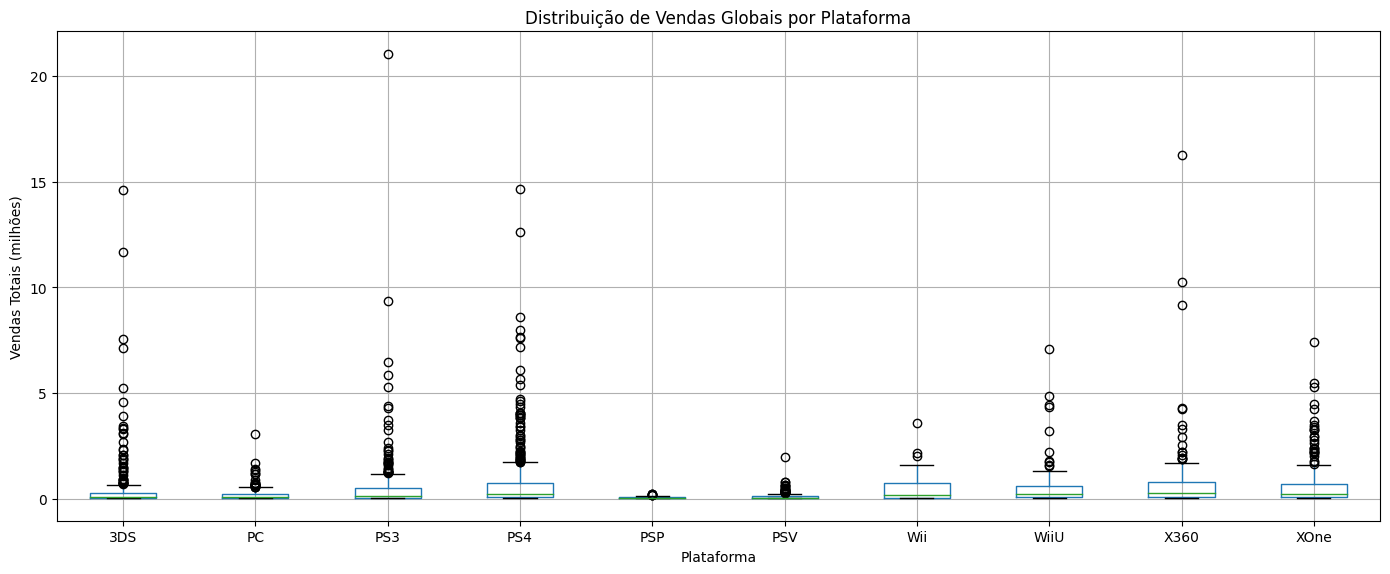

=== VENDAS MÉDIAS POR PLATAFORMA ===
platform
PS4     0.80
X360    0.74
XOne    0.65
Wii     0.59
WiiU    0.56
PS3     0.53
3DS     0.47
PC      0.21
PSV     0.09
PSP     0.05
Name: total_sales, dtype: float64


In [35]:

import matplotlib.pyplot as plt

# filtrar top plataformas para o gráfico não ficar poluído
top_platforms = df_recente.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10).index
df_top = df_recente[df_recente['platform'].isin(top_platforms)]

# boxplot
fig, ax = plt.subplots(figsize=(14, 6))
df_top.boxplot(column='total_sales', by='platform', ax=ax)
ax.set_title('Distribuição de Vendas Globais por Plataforma')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Vendas Totais (milhões)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('boxplot_sales.png')
plt.show()

# vendas médias por plataforma
print("=== VENDAS MÉDIAS POR PLATAFORMA ===")
print(df_top.groupby('platform')['total_sales'].mean().sort_values(ascending=False).round(2))

> Como analisado anteriormente as médias provam, que a modernidade vem com tudo para 2017, consoles modernos devem ser a pedida e escolha para novos jogos, tendo em mente que não deixando de lado plataformas ainda rentavéis, até o moderno assumir totalmente o posto de top lucratividade e as antigas irem deixando seu lugar. Detalhe para o outlier lá no topo do PS3/PS4 e outros consoles como Xbox e 3DS, mostrando o quanto as médias e vendas totais dos mesmos, tem total ligação.

## Plotagem de gráficos

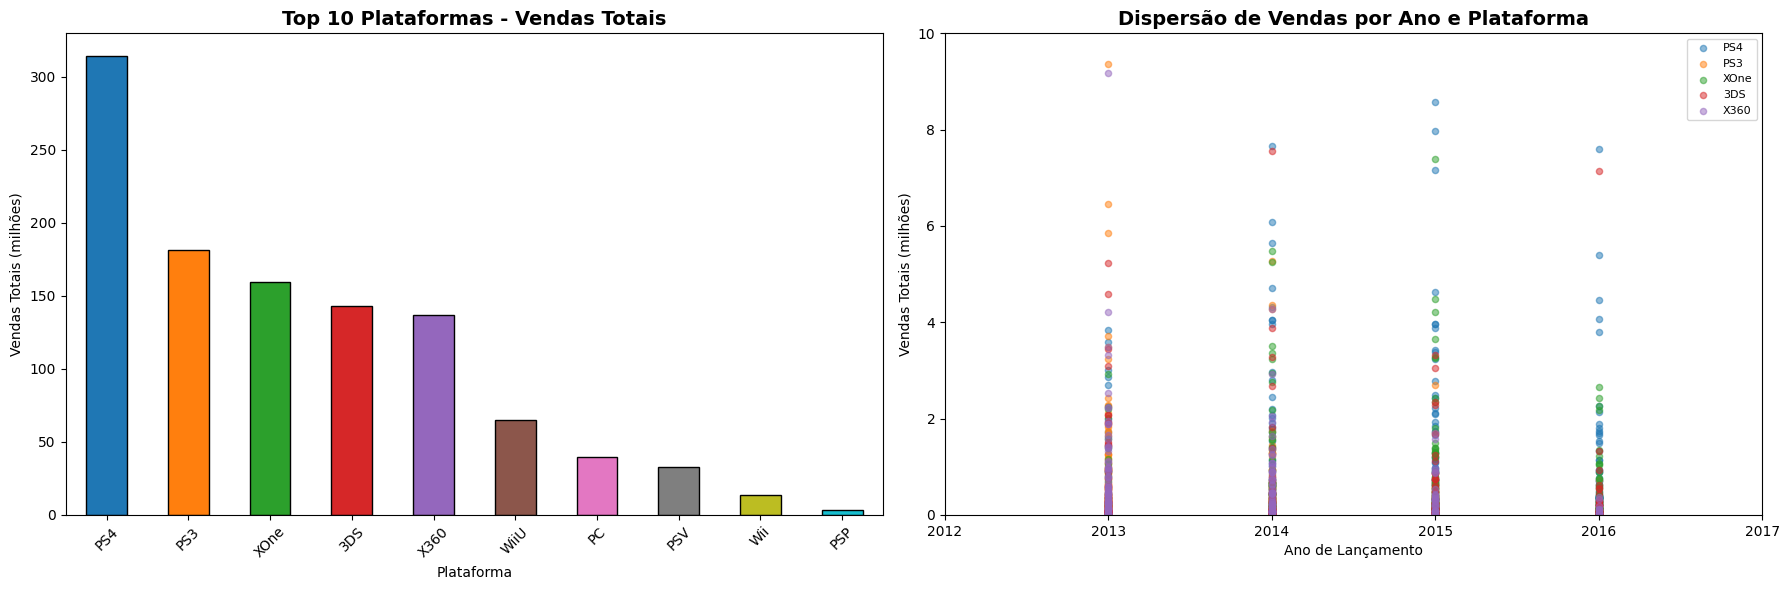

=== PLATAFORMAS POTENCIALMENTE LUCRATIVAS ===
platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
Name: total_sales, dtype: float64


In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# vendas totais por plataforma (barras)
colors = plt.cm.tab10.colors
platform_sales.head(10).plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Top 10 Plataformas - Vendas Totais', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Vendas Totais (milhões)')
axes[0].tick_params(axis='x', rotation=45)

# dispersão top 5 plataformas
top_platforms = platform_sales.head(5).index
df_top = df_recente[df_recente['platform'].isin(top_platforms)].dropna(subset=['year_of_release'])

for platform in top_platforms:
    dados = df_top[df_top['platform'] == platform]
    axes[1].scatter(dados['year_of_release'], dados['total_sales'],
                    label=platform, alpha=0.5, s=20)

axes[1].set_title('Dispersão de Vendas por Ano e Plataforma', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ano de Lançamento')
axes[1].set_ylabel('Vendas Totais (milhões)')
axes[1].set_ylim(0, 10)
axes[1].set_xlim(2012, df_top['year_of_release'].max() + 1)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('platform_sales.png', dpi=150)
plt.show()

# plataformas potencialmente lucrativas
ano_atual = df_recente['year_of_release'].dropna().max()
platform_data = df_recente.dropna(subset=['year_of_release']).groupby('platform')['year_of_release'].agg(['min', 'max'])
ativas = platform_data[platform_data['max'] == ano_atual].index

print("=== PLATAFORMAS POTENCIALMENTE LUCRATIVAS ===")
print(platform_sales[platform_sales.index.isin(ativas)].head(10))

> Com o recorte a partir de 2013, o PS4 se destaca como a plataforma com maior potencial de lucratividade no período recente. Ainda ativa e com volume expressivo de vendas, consolida a Sony como líder de mercado nesse ciclo de geração de consoles — tornando-se a escolha mais segura para novos investimentos em jogos. Sucedido, também pela microsoft com seus expressivos números, apesar de abaixo da Sony.

## Como as avaliações de usuários e profissionais afetam as vendas

Usarei o 'PS4' por ser uma plataforma com potencial lucrativo

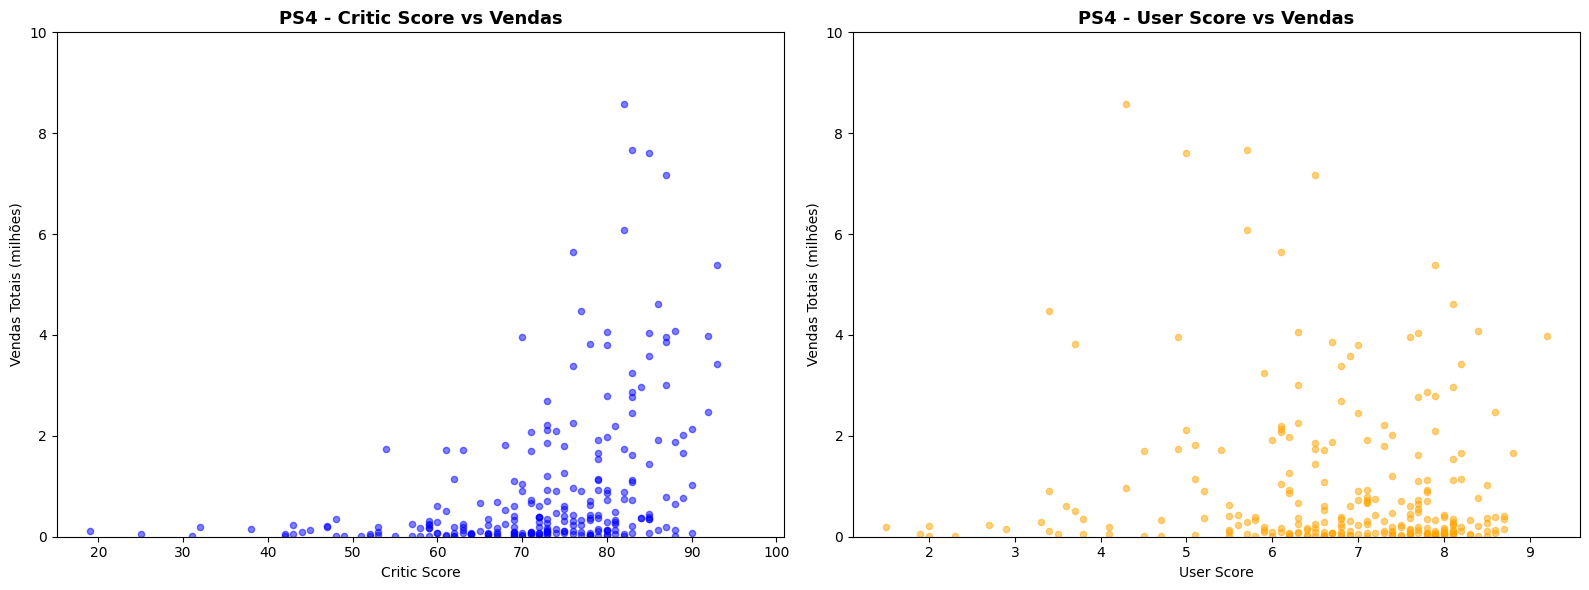

=== CORRELAÇÃO — PS4 ===
Critic Score x Vendas: 0.41
User Score x Vendas:   -0.03

Avaliação de críticos tem MAIS influência nas vendas


In [43]:
plataforma = 'PS4'
df_x360 = df_recente[df_recente['platform'] == plataforma].dropna(subset=['critic_score', 'user_score', 'total_sales'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# critic score x vendas
axes[0].scatter(df_x360['critic_score'], df_x360['total_sales'], alpha=0.5, s=20, color='blue')
axes[0].set_title(f'{plataforma} - Critic Score vs Vendas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Vendas Totais (milhões)')
axes[0].set_ylim(0, 10)

# user score x vendas
axes[1].scatter(df_x360['user_score'], df_x360['total_sales'], alpha=0.5, s=20, color='orange')
axes[1].set_title(f'{plataforma} - User Score vs Vendas', fontsize=13, fontweight='bold')
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Vendas Totais (milhões)')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig('score_vs_sales.png', dpi=150)
plt.show()

# correlação, criando o criterio de comparação entre critic e user score para vendas
corr_critic = df_x360['critic_score'].corr(df_x360['total_sales'])
corr_user = df_x360['user_score'].corr(df_x360['total_sales'])

print(f"=== CORRELAÇÃO — {plataforma} ===")
print(f"Critic Score x Vendas: {corr_critic:.2f}")
print(f"User Score x Vendas:   {corr_user:.2f}")

if corr_critic > corr_user:
    print("\nAvaliação de críticos tem MAIS influência nas vendas")
else:
    print("\nAvaliação de usuários tem MAIS influência nas vendas")

> Como observado nos gráficos e correlações, as avaliações de críticos influenciam mais as vendas do que as dos usuários no PS4, mas nenhuma das duas é um fator determinante — as correlações se mantêm distantes de 1,0. Isso sugere que outros fatores como marketing, franquia, exclusividade e preço provavelmente têm peso maior nas vendas do que as notas em si.

## 1. Comparando um jogo em diferentes plataformas

## 2. Logo abaixo análise por gêneros dos jogos e lucratividade

In [44]:

# buscando jogos que foram lançados em 4 ou mais plataformas, para o gráfico de comparação entre plataformas
jogos_multiplataforma = df_recente.groupby('name')['platform'].nunique()
print(jogos_multiplataforma[jogos_multiplataforma >= 4].sort_values(ascending=False).head(5))

name
LEGO Marvel Super Heroes    9
FIFA 14                     9
LEGO The Hobbit             8
The LEGO Movie Videogame    8
FIFA 15                     8
Name: platform, dtype: int64


> Escolha: LEGO Marvel Super Heroes

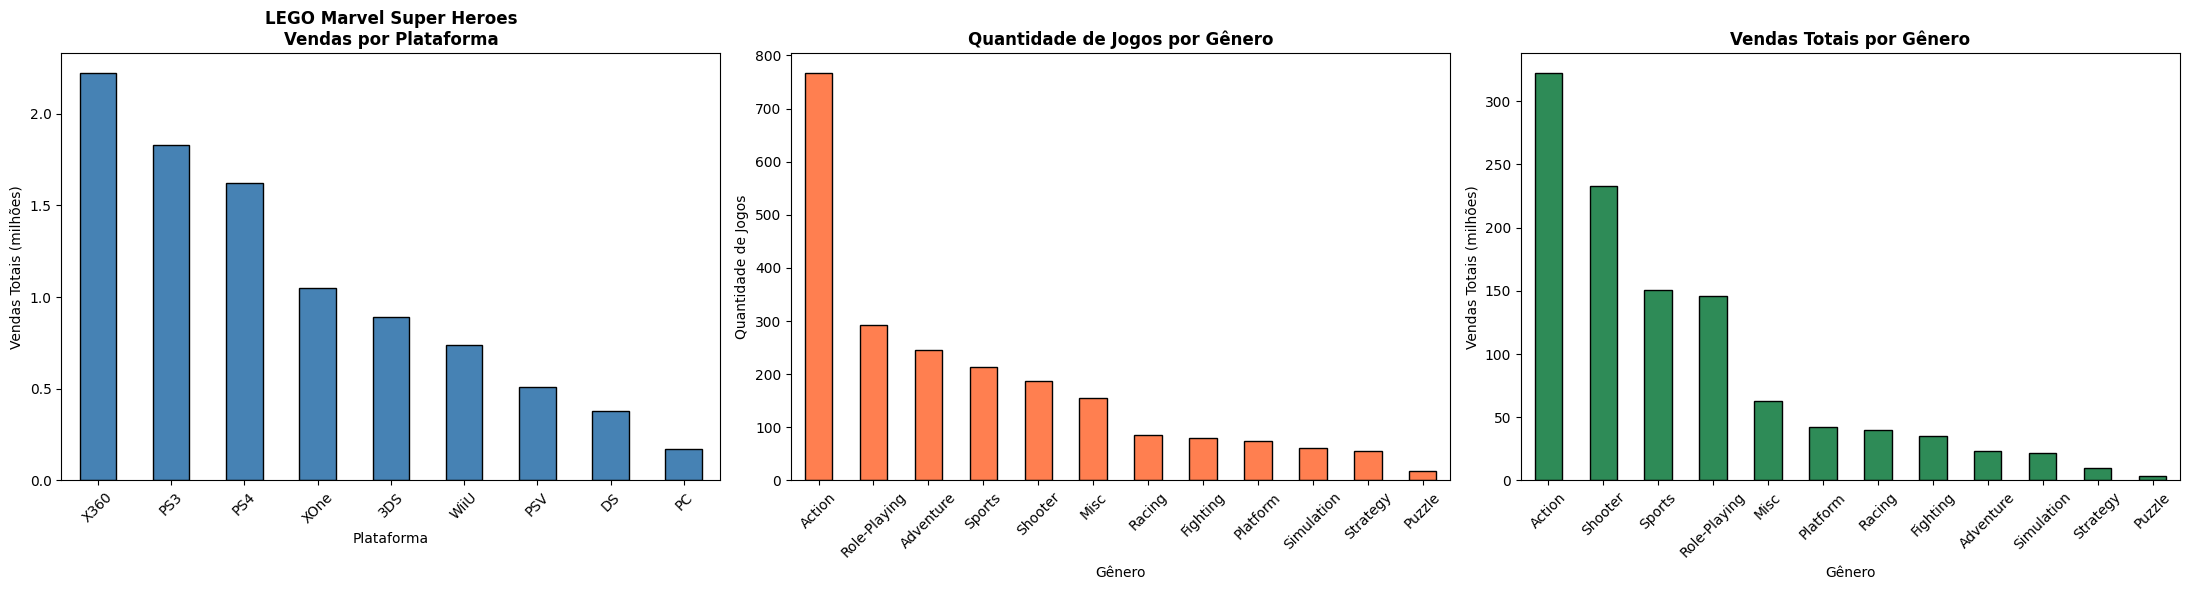

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# mesmo jogo em diferentes plataformas
jogo = 'LEGO Marvel Super Heroes'
df_jogo = df_recente[df_recente['name'] == jogo].groupby('platform')['total_sales'].sum().sort_values(ascending=False)
df_jogo.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title(f'{jogo}\nVendas por Plataforma', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Vendas Totais (milhões)')
axes[0].tick_params(axis='x', rotation=45)

# quantidade de jogos por gênero
genre_count = df_recente['genre'].value_counts()
genre_count.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Quantidade de Jogos por Gênero', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gênero')
axes[1].set_ylabel('Quantidade de Jogos')
axes[1].tick_params(axis='x', rotation=45)

# vendas totais por gênero
genre_sales = df_recente.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales.plot(kind='bar', ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title('Vendas Totais por Gênero', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Gênero')
axes[2].set_ylabel('Vendas Totais (milhões)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('genre_analysis.png', dpi=150)
plt.show()

> O LEGO Marvel Super Heroes teve melhor desempenho no X360 e PS3, plataformas ainda relevantes no início do período analisado (2013), seguidas de perto pelo PS4 e XOne — consoles que assumiram o mercado na sequência. Isso reforça a força dos títulos multiplataforma para maximizar alcance e receita.

> Em relação aos gêneros, Action lidera tanto em quantidade de jogos lançados quanto em vendas totais no período recente, confirmando ser o gênero mais seguro para investimento. Shooter e Sports aparecem logo atrás em vendas, enquanto Role-Playing se destaca em quantidade de lançamentos mas com vendas menores — indicando um mercado mais fragmentado nesse gênero.

In [46]:
# vendas médias por gênero (lucratividade real)
print("=== VENDAS MEDIAS POR JOGO (lucratividade por genero) ===")
print(df_recente.groupby('genre')['total_sales'].mean().sort_values(ascending=False))

=== VENDAS MEDIAS POR JOGO (lucratividade por genero) ===
genre
Shooter         1.245882
Sports          0.703972
Platform        0.576081
Role-Playing    0.499623
Racing          0.469294
Fighting        0.441375
Action          0.420196
Misc            0.405290
Simulation      0.350968
Puzzle          0.186471
Strategy        0.180000
Adventure       0.096490
Name: total_sales, dtype: float64


> Na análise do período recente (2013 em diante), ficou evidente que **Action** é lucrativo por volume — muitos jogos vendendo razoavelmente — enquanto **Shooter** se destaca como lucrativo por qualidade, com menos jogos mas média de vendas por título mais alta.

> Analisando a média de vendas por jogo no período recente, **Shooter** lidera com folga, confirmando ser o gênero mais lucrativo por qualidade — impulsionado por franquias dominantes como Call of Duty. **Sports** aparece em segundo, sustentado por séries anuais consolidadas como FIFA e NBA. **Platform** vem em terceiro, ainda forte graças a franquias clássicas. Já **Action**, apesar de liderar em volume total de jogos e vendas absolutas, aparece apenas em 7º lugar na média — evidenciando que o gênero é competitivo, porém fragmentado, com muitos títulos dividindo o mercado.

# Etapa 4: Criando um perfil de usuário para cada região

Para cada região (NA, EU, JP), determinaremos:

+ As cinco plataformas principais.
+ Os cinco principais gêneros.
+ As classificações do ESRB afetam as vendas em regiões individuais?

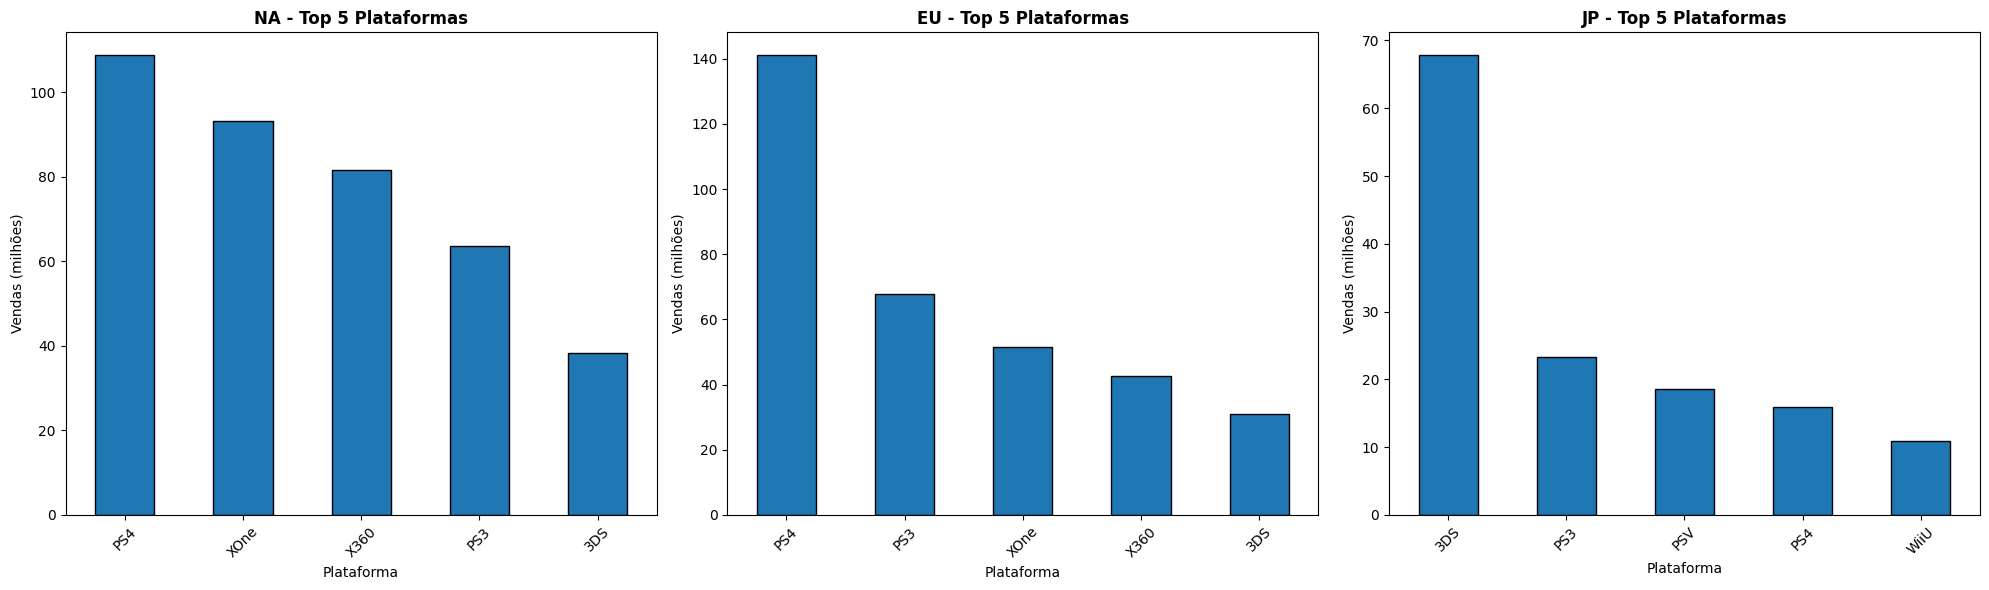

In [47]:
# usando plotagem de gráficos e fazendo divisão por região
# top 5 plataformas por região:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
region = {'NA': 'na_sales', 'EU': 'eu_sales', 'JP': 'jp_sales'}

for col, (region_name, coluna) in enumerate(region.items()):
    top_plat = df_recente.groupby('platform')[coluna].sum().sort_values(ascending=False).head(5)
    top_plat.plot(kind='bar', ax=axes[col], edgecolor='black')
    axes[col].set_title(f'{region_name} - Top 5 Plataformas', fontsize=12, fontweight='bold')
    axes[col].set_xlabel('Plataforma')
    axes[col].set_ylabel('Vendas (milhões)')
    axes[col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('top_plataformas.png', dpi=150)
plt.show()

> Pode-se notar a presença das grandes empresas dos games como Xbox e Playstation apenas em diferentes ordens de mais vendas por região. Entretanto, um detalhe ficou mais claro que em NA e EU temos um mesmo 'campeão', a valiosa empresa Sony no mundo dos games, mostrando sua força nas variadas regiões do mundo. Apesar de que no Japão termos uma liderança do 3DS, e em seguida novamente a Sony presente.

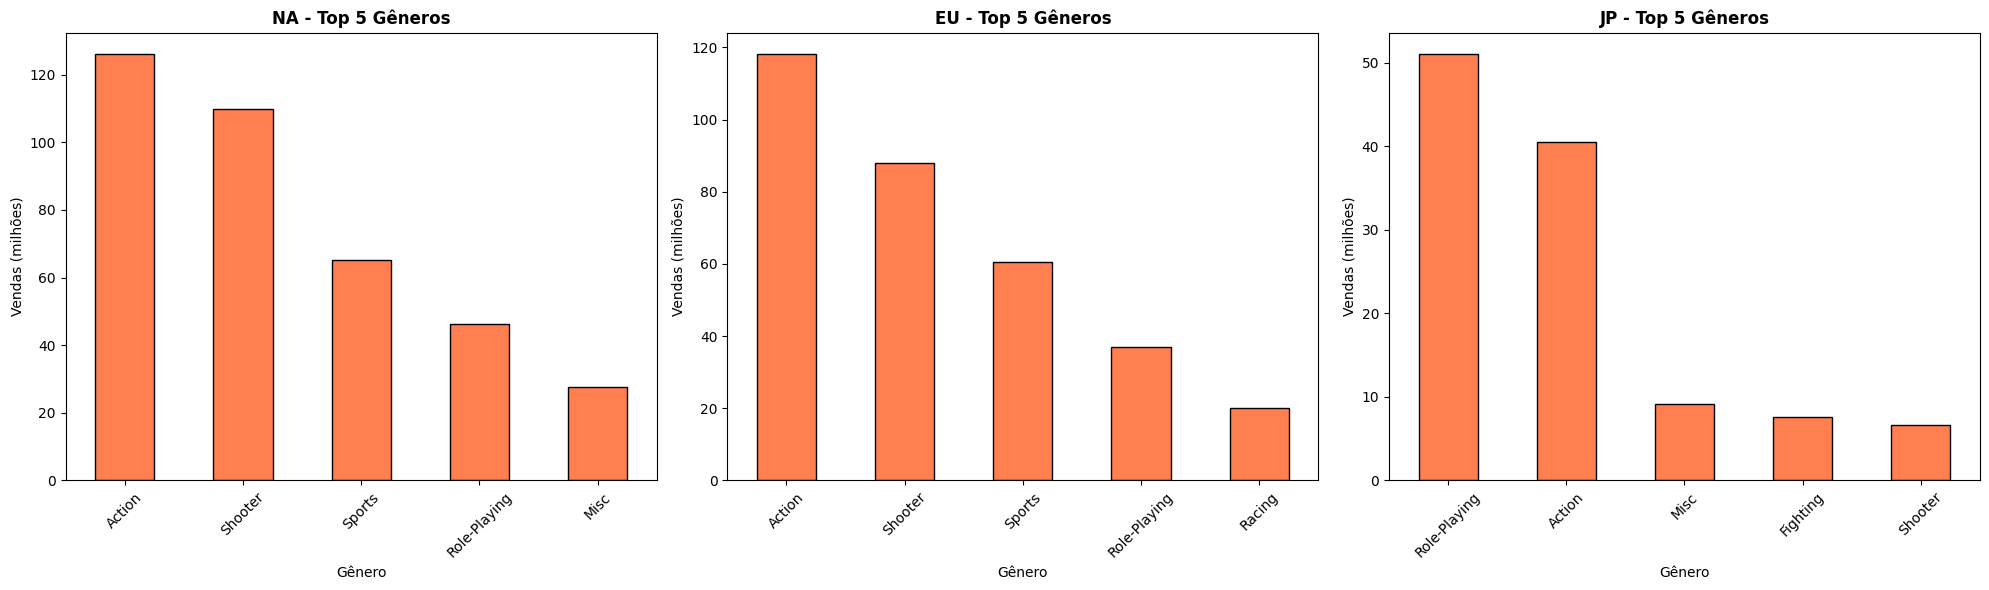

In [48]:
# Top 5 gêneros por região:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for col, (region_name, coluna) in enumerate(region.items()):
    top_gen = df_recente.groupby('genre')[coluna].sum().sort_values(ascending=False).head(5)
    top_gen.plot(kind='bar', ax=axes[col], color='coral', edgecolor='black')
    axes[col].set_title(f'{region_name} - Top 5 Gêneros', fontsize=12, fontweight='bold')
    axes[col].set_xlabel('Gênero')
    axes[col].set_ylabel('Vendas (milhões)')
    axes[col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('top_generos.png', dpi=150)
plt.show()

> A análise regional de gêneros revela padrões culturais bem distintos. **NA e EU** compartilham o mesmo pódio — Action e Shooter dominam com folga, seguidos de Sports, refletindo o gosto ocidental por jogos competitivos e de alto impacto. **JP** quebra completamente esse padrão: Role-Playing lidera com ampla vantagem, seguido de Action e Misc — evidenciando a forte cultura japonesa de RPGs narrativos, com Shooter aparecendo apenas em último lugar no top 5, com volume bem inferior ao ocidental.

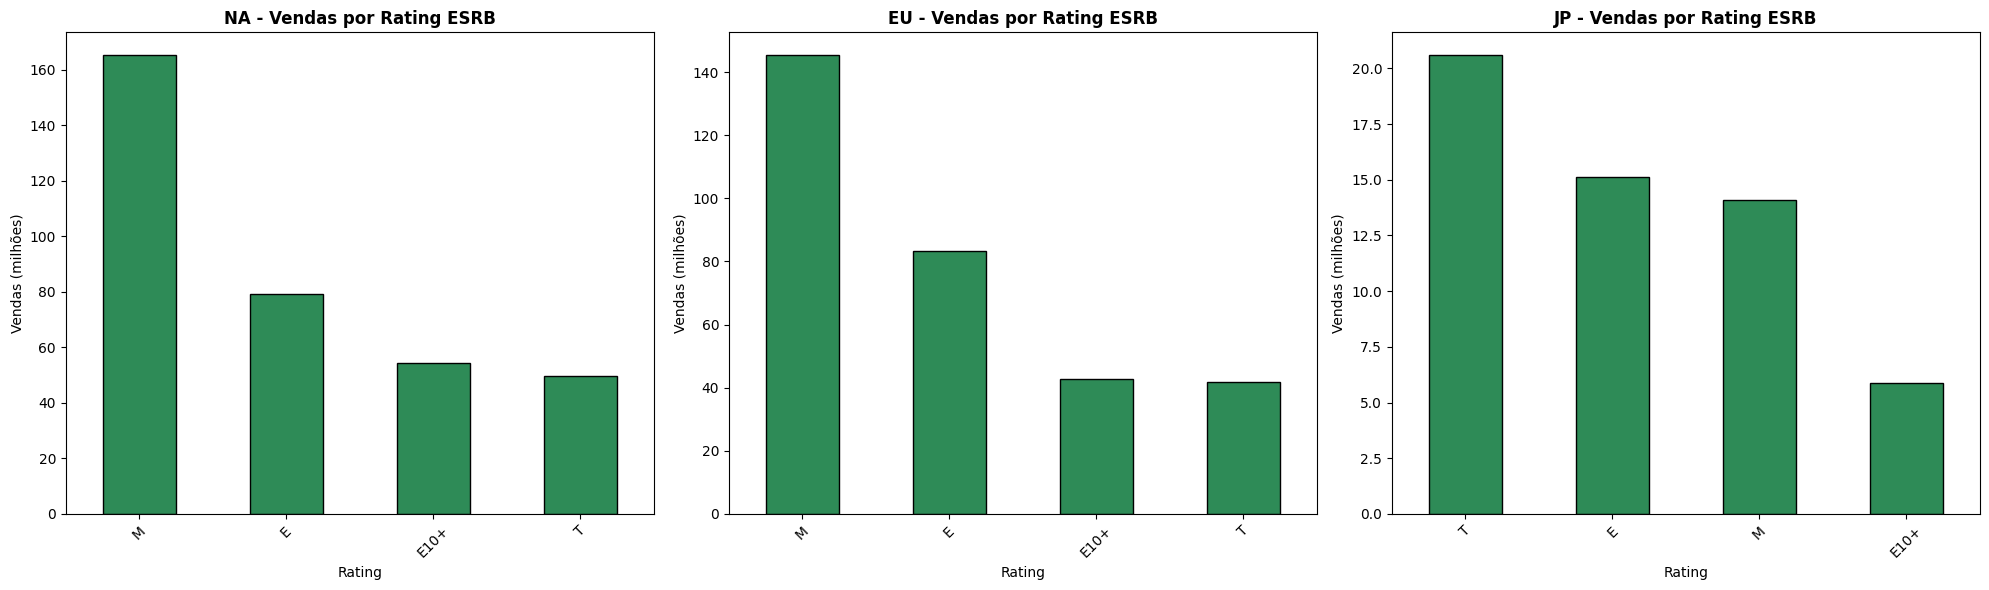

In [49]:
# ESRB Rating por região:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for col, (region_name, coluna) in enumerate(region.items()):
    top_rating = df_recente.dropna(subset=['rating']).groupby('rating')[coluna].sum().sort_values(ascending=False)
    top_rating.plot(kind='bar', ax=axes[col], color='seagreen', edgecolor='black')
    axes[col].set_title(f'{region_name} - Vendas por Rating ESRB', fontsize=12, fontweight='bold')
    axes[col].set_xlabel('Rating')
    axes[col].set_ylabel('Vendas (milhões)')
    axes[col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('esrb_rating.png', dpi=150)
plt.show()

> O rating **M (Mature, 17+)** domina as vendas em NA e EU com folga, impulsionado por grandes franquias como GTA e Call of Duty que concentram muito volume nessa classificação. Em segundo vem o **E (Everyone)**, seguido de **E10+** e **T (Teen)** com valores próximos entre si. O JP quebra o padrão: **T** lidera, refletindo o perfil mais jovem e familiar dos jogos mais populares no mercado japonês, com M aparecendo apenas em terceiro. Em todas as regiões o rating ESRB impacta as vendas, mas mais pelo perfil dos títulos que carregam cada classificação do que pela classificação em si.

# Etapa 5: Testes de hipóteses

— As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.

— As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.

Explicar:

— Como formulei as hipóteses alternativas e nulas.

— Qual o nível de significância que escolhi para testar as hipóteses, e por quê.

In [26]:
# nível de significância em 5% para testes estatísticos, por ser o padrão
alpha = 0.05

In [50]:
# teste de hipótese entre xbox e pc
from scipy import stats

# H0: a média de avaliações dos usuários no Xbox One e PC são iguais
# H1: a média de avaliações dos usuários no Xbox One e PC são diferentes

xboxone = df_recente[df_recente['platform'] == 'XOne']['user_score'].dropna()
pc = df_recente[df_recente['platform'] == 'PC']['user_score'].dropna()

# Avaliar se as variâncias são iguais
var_xbox = xboxone.var()
var_pc = pc.var()
print(f"Variância Xbox One: {var_xbox:.4f}")
print(f"Variância PC: {var_pc:.4f}")
equal_var = var_xbox == var_pc
print(f"Variâncias iguais: {equal_var}")

# Teste T ajustado conforme resultado da variância
stat, p_value = stats.ttest_ind(xboxone, pc, equal_var=equal_var)

print(f"\nTeste Xbox One vs PC")
print(f"p-value: {p_value:.4f}")
print(f"Alpha: {alpha}")

if p_value < alpha:
    print("Resultado: REJEITA H0 — as médias são diferentes")
else:
    print("Resultado: NÃO rejeita H0 — as médias são iguais")

Variância Xbox One: 1.9070
Variância PC: 3.0359
Variâncias iguais: False

Teste Xbox One vs PC
p-value: 0.1476
Alpha: 0.05
Resultado: NÃO rejeita H0 — as médias são iguais


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Precisamos seguir estes passos para o teste de hipótese:
- Definir a hipótese nula (ex: a altura média é igual entre homem e mulheres)
- Definir a hipótese alternativa (ex: a altura média não é igual entre homem e mulheres)
- Avaliar se as variâncias são iguais, por exemplo, calculando a variância da amostra e verificando a igualdade (ex: sample1.var() == sample2.var())
- Em seguida, ajustar equal_var=True no teste T se as variâncias forem iguais, senão usamos equal_var=False no teste T: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html.
- Avaliar o resultado do teste T

</div>

> **H0:** a média de avaliações dos usuários no Xbox One e PC são iguais.
> **H1:** a média de avaliações dos usuários no Xbox One e PC são diferentes.

> As variâncias das amostras são diferentes (Xbox One: 1.91, PC: 3.04), portanto o teste T foi aplicado com `equal_var=False`. Com p-value de 0.1476 e alpha de 0.05, **não rejeitamos H0** — não há evidências estatísticas suficientes para afirmar que as médias de avaliação dos usuários entre Xbox One e PC são diferentes no período recente.

Correção feita

In [51]:
# teste de hipótese entre gêneros Action e Sports, para ver se os usuários avaliam de forma diferente esses gêneros

# H0: a média de avaliações dos usuários para Action e Sports são iguais
# H1: a média de avaliações dos usuários para Action e Sports são diferentes

action = df_recente[df_recente['genre'] == 'Action']['user_score'].dropna()
sports = df_recente[df_recente['genre'] == 'Sports']['user_score'].dropna()

# Avaliar se as variâncias são iguais
var_action = action.var()
var_sports = sports.var()
print(f"Variância Action: {var_action:.4f}")
print(f"Variância Sports: {var_sports:.4f}")
equal_var = var_action == var_sports
print(f"Variâncias iguais: {equal_var}")

# Teste T ajustado conforme resultado da variância
stat, p_value = stats.ttest_ind(action, sports, equal_var=equal_var)

print(f"\nTeste Action vs Sports")
print(f"p-value: {p_value:.4f}")
print(f"Alpha: {alpha}")

if p_value < alpha:
    print("Resultado: REJEITA H0 — as médias são diferentes")
else:
    print("Resultado: NÃO rejeita H0 — as médias são iguais")

Variância Action: 1.7694
Variância Sports: 3.1806
Variâncias iguais: False

Teste Action vs Sports
p-value: 0.0000
Alpha: 0.05
Resultado: REJEITA H0 — as médias são diferentes


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Precisamos seguir estes passos para o teste de hipótese:
- Definir a hipótese nula (ex: a altura média é igual entre homem e mulheres)
- Definir a hipótese alternativa (ex: a altura média não é igual entre homem e mulheres)
- Avaliar se as variâncias são iguais, por exemplo, calculando a variância da amostra e verificando a igualdade (ex: sample1.var() == sample2.var())
- Em seguida, ajustar equal_var=True no teste T se as variâncias forem iguais, senão usamos equal_var=False no teste T: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html.
- Avaliar o resultado do teste T

</div>

> **H0:** a média de avaliações dos usuários para Action e Sports são iguais.
> **H1:** a média de avaliações dos usuários para Action e Sports são diferentes.

> As variâncias das amostras são diferentes (Action: 1.77, Sports: 3.18), portanto o teste T foi aplicado com `equal_var=False`. Com p-value de 0.0000 e alpha de 0.05, **rejeitamos H0** — há evidências estatísticas suficientes para afirmar que os usuários avaliam de forma diferente os gêneros Action e Sports, sendo resultados opostos ao teste anterior entre plataformas.

Correção feita

# **Conclusão**

> **Qualidade dos Dados:**
> O dataset passou por um processo de limpeza essencial: padronização dos nomes das colunas, conversão de tipos (user_score de object para float, year_of_release para Int64), tratamento de valores ausentes e criação da coluna total_sales para facilitar as análises de vendas globais. A partir da seção de plataformas, todas as análises foram realizadas com dados recortados para o período de 2013 em diante, garantindo maior relevância e aderência ao mercado atual.

> **Plataformas:**
> No período recente, PS4 se consolidou como a plataforma de maior potencial lucrativo, liderando as vendas e ainda ativa no mercado. A análise de correlação com o PS4 confirmou o padrão já observado anteriormente: avaliações de críticos têm influência moderada nas vendas, enquanto avaliações de usuários têm peso menor — reforçando que marketing, franquia e exclusividade são fatores mais determinantes que as notas em si.

> **Gêneros:**
> Shooter lidera a média de vendas por título (~1.25M), impulsionado por franquias dominantes como Call of Duty. Action, apesar de liderar em volume total, aparece apenas em 7º na média — evidenciando um mercado fragmentado e competitivo. Sports e Platform se mantêm sólidos, sustentados por séries anuais e franquias clássicas respectivamente.

> **Análise Regional:**
> NA e EU compartilham preferências semelhantes — Action e Shooter dominam os gêneros, com o rating M (Mature) liderando as vendas em ambas as regiões. O JP mantém seu perfil cultural distinto: Role-Playing lidera com folga nos gêneros e o rating T (Teen) prevalece nas vendas, com volume total bem inferior ao ocidental.

> **Testes de Hipótese:**
> Com o recorte a partir de 2013, o teste entre Xbox One e PC não rejeitou H0 (p-value: 0.1476) — não há evidências de que as médias de avaliação dos usuários sejam diferentes entre as plataformas no período recente. Já o teste entre Action e Sports rejeitou H0 (p-value ≈ 0) — confirmando que os usuários avaliam esses gêneros de forma estatisticamente diferente.

> **Observação final:** Para novos investimentos, PS4 é a plataforma mais segura e lucrativa do período analisado. Em gêneros, Shooter oferece o maior retorno médio por título, enquanto Action garante volume. Regionalmente, o mercado ocidental (NA e EU) favorece títulos Mature de ação e tiro, enquanto o JP demanda uma estratégia própria focada em RPGs — reforçando que uma abordagem regionalizada é essencial para maximizar resultados.